# GP DF Inference 
Here we perform bayesian inference on the dataset generated by IBM simulations with GP parameterised vital rates 

In [1]:
import pandas as pd
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import hpdi
from numpyro.infer import MCMC, NUTS, Predictive
from dl4bi_sps.kernels import rbf

import matplotlib.pyplot as plt

num_warmup = 1000
num_samples = 5000

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('gp_ibm_dataset.csv')

In [3]:
df.describe().round(3)

,z,Repr,Seeds,Surv,z1,age,yr
count,749.000,749.000,16.000,733.000,308.000,749.000,749.000
mean,0.427,0.021,2484.125,0.420,1.456,0.502,2.963
std,1.035,0.145,2336.465,0.494,0.807,0.910,1.666
min,-2.042,0.000,143.000,0.000,-0.872,0.000,1.000
25%,-0.300,0.000,741.500,0.000,0.908,0.000,1.000
50%,0.302,0.000,1756.000,0.000,1.484,0.000,3.000
75%,1.144,0.000,3209.250,1.000,2.007,1.000,5.000
max,3.653,1.000,8289.000,1.000,3.653,4.000,5.000


In [4]:
s_surv = df[df['Repr'] == 0]['z'].values
y_surv = df[df['Repr'] == 0]['Surv'].values

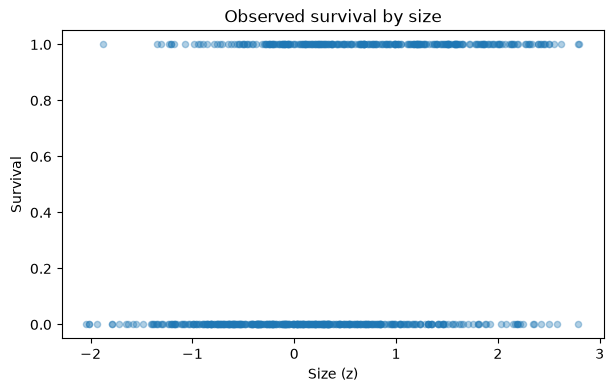

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(s_surv, y_surv, alpha=0.35, s=20)
plt.xlabel("Size (z)")
plt.ylabel("Survival")
plt.title("Observed survival by size")
plt.show()

In [6]:
s_repr = df[df['Repr'].notna()]['z'].values
y_repr = df[df['Repr'].notna()]['Repr'].values

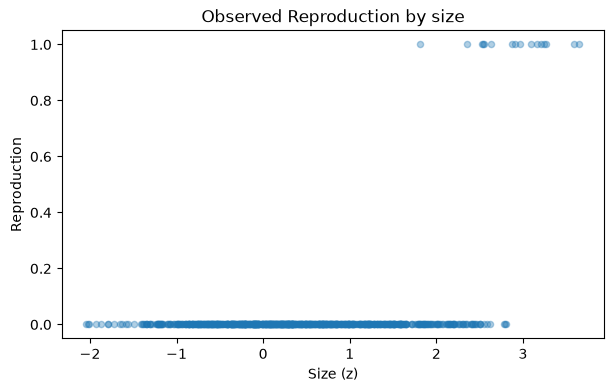

In [7]:
plt.figure(figsize=(7, 4))
plt.scatter(s_repr, y_repr, alpha=0.35, s=20)
plt.xlabel("Size (z)")
plt.ylabel("Reproduction")
plt.title("Observed Reproduction by size")
plt.show()

In [8]:
s_seed = df[df['Seeds'].notna()]['z'].values
y_seed = df[df['Seeds'].notna()]['Seeds'].values

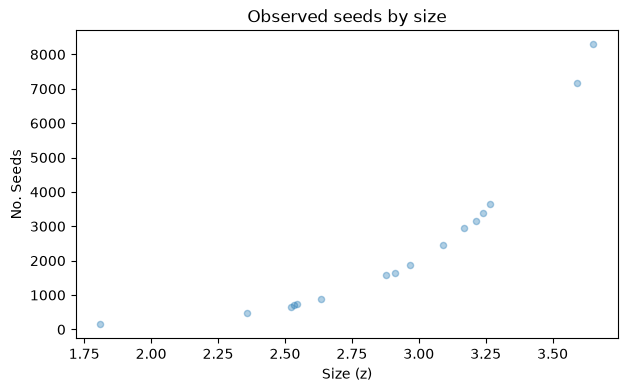

In [9]:
plt.figure(figsize=(7, 4))
plt.scatter(s_seed, y_seed, alpha=0.35, s=20)
plt.xlabel("Size (z)")
plt.ylabel("No. Seeds")
plt.title("Observed seeds by size")
plt.show()

In [10]:
s_growth = df[df['z1'].notna()]['z'].values
y_growth = df[df['z1'].notna()]['z1'].values

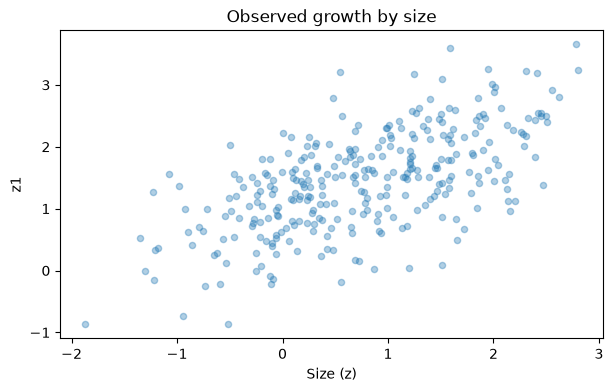

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(s_growth, y_growth, alpha=0.35, s=20)
plt.xlabel("Size (z)")
plt.ylabel("z1")
plt.title("Observed growth by size")
plt.show()

In [12]:
def survival_inference_model_glm(s, y, priors):
    intercept = numpyro.sample('int', priors['surv_int'])
    slope = numpyro.sample('slope', priors['surv_slope'])
    mu = intercept + slope * s
    p = jax.nn.sigmoid(mu)
    numpyro.sample('surv', dist.Bernoulli(p), obs = y)

In [13]:
def repr_inference_model_glm(s, y, priors):
    intercept = numpyro.sample('int', priors['repr_int'])
    slope = numpyro.sample('slope', priors['repr_slope'])
    mu = intercept + slope * s
    p = jax.nn.sigmoid(mu)
    numpyro.sample('repr', dist.Bernoulli(p), obs = y)


In [14]:
def seed_inference_model_glm(s, y, priors):
    intercept = numpyro.sample('int', priors['seed_int'])
    slope = numpyro.sample('slope', priors['seed_slope'])
    mu = intercept + slope * s
    lambda_ = jnp.exp(mu)
    numpyro.sample('seed', dist.Poisson(lambda_), obs = y)

In [15]:
def growth_inference_model_glm(s, y, priors):
    intercept = numpyro.sample('int', priors['growth_int'])
    slope = numpyro.sample('slope', priors['growth_slope'])
    noise = numpyro.sample('noise', priors['growth_noise'])
    mu = intercept + slope * s
    numpyro.sample('z1', dist.Normal(mu, noise), obs = y)

In [16]:
glm_priors = {
    'surv_int': dist.Normal(0,1),
    'surv_slope': dist.Normal(0,1),
    'repr_int': dist.Normal(0,1),
    'repr_slope': dist.Normal(0,1),
    'seed_int': dist.Normal(0,1),
    'seed_slope': dist.Normal(0,1),
    'growth_int': dist.Normal(0,1),
    'growth_slope': dist.Normal(0,1),
    'growth_noise': dist.Normal(0,1),
}

glm_models = {
    'surv': survival_inference_model_glm,
    'repr': repr_inference_model_glm,
    'seed': seed_inference_model_glm,
    'growth': growth_inference_model_glm
}

vr_data = {
    'surv': [s_surv, y_surv],
    'repr': [s_repr, y_repr],
    'seed': [s_seed, y_seed],
    'growth': [s_growth, y_growth]
}

 

In [17]:
def prior_predictive_check_glm(rng, model_key, models, data, num_samples, priors):
    s = data[model_key][0]
    y = data[model_key][1]
    model = models[model_key]
    if model_key == 'growth':
        prior_pred = Predictive(model, num_samples=num_samples, return_sites=["int", "slope", 'noise', 'z1'],)
        prior_samples = prior_pred(rng, s=s, y=None, priors=priors)
        param = prior_samples["int"][:, None] + prior_samples["slope"][:, None] * s[None, :]
        y_prior = prior_samples["z1"]

    else:
        prior_pred = Predictive(model, num_samples=num_samples, return_sites=["int", "slope", f"{model_key}"],)
        prior_samples = prior_pred(rng, s=s, y=None, priors=priors)
        mu_prior = prior_samples["int"][:, None] + prior_samples["slope"][:, None] * s[None, :]      
        if model_key == 'surv' or model_key == 'repr':
            param = jax.nn.sigmoid(mu_prior)     
        elif model_key == 'seed':
            param = jnp.exp(mu_prior)

    sort_idx = jnp.argsort(s)
    s_sorted = s[sort_idx]
    y_sorted = y[sort_idx]
    if model_key == 'growth':
        for i in range(20):
            plt.plot(s_sorted, y_prior[i][sort_idx], alpha=0.2)
    else:
        for i in range(20):
            plt.plot(s_sorted, param[i][sort_idx], alpha=0.3)

    plt.scatter(s_sorted, y_sorted, color="black", s=10, alpha=0.8, label="Observed data")
    plt.xlabel("s")
    if model_key == 'growth':
        plt.ylabel("s1")
    elif model_key == 'surv' or model_key == 'repr':
        plt.ylabel('Prob')
    elif model_key == 'seed':
        plt.ylabel('Count')
    plt.show()
    return param

In [18]:
rng = random.key(0)
rng_surv, rng = random.split(rng, 2)

kernel = NUTS(survival_inference_model_glm)
mcmc = MCMC(kernel, num_warmup = num_warmup, num_samples = num_samples)
mcmc.run(rng_surv, s = s_surv, y = y_surv, priors = glm_priors)
mcmc.print_summary()
surv_samples = mcmc.get_samples()


sample: 100%|██████████| 6000/6000 [00:01<00:00, 4034.79it/s, 3 steps of size 7.70e-01. acc. prob=0.92]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -0.64      0.09     -0.64     -0.78     -0.50   2518.07      1.00
     slope      0.77      0.09      0.77      0.63      0.92   2493.49      1.00

Number of divergences: 0


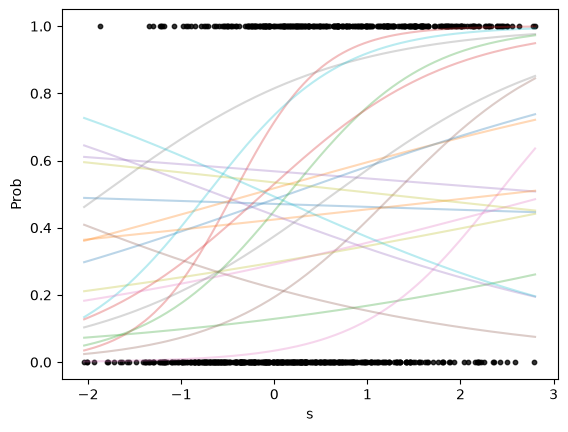

In [19]:
rng_surv_check, rng = random.split(rng, 2)
prior_prob = prior_predictive_check_glm(rng_surv_check, 'surv', glm_models, vr_data, 100, glm_priors)

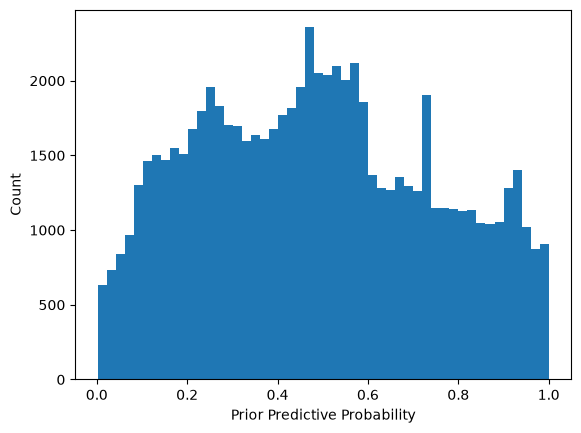

In [20]:
plt.hist(jnp.ravel(prior_prob), bins=50)
plt.xlabel("Prior Predictive Probability")
plt.ylabel("Count")
plt.show()

In [21]:
rng_repr, rng = random.split(rng, 2)

kernel = NUTS(repr_inference_model_glm)
mcmc = MCMC(kernel, num_warmup = num_warmup, num_samples = num_samples)
mcmc.run(rng_surv, s = s_repr, y = y_repr, priors = glm_priors)
mcmc.print_summary()
repr_samples = mcmc.get_samples()


sample: 100%|██████████| 6000/6000 [00:01<00:00, 3709.64it/s, 11 steps of size 3.60e-01. acc. prob=0.92]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -5.64      0.47     -5.61     -6.42     -4.86   1471.08      1.00
     slope      1.67      0.23      1.67      1.30      2.06   1375.95      1.00

Number of divergences: 0


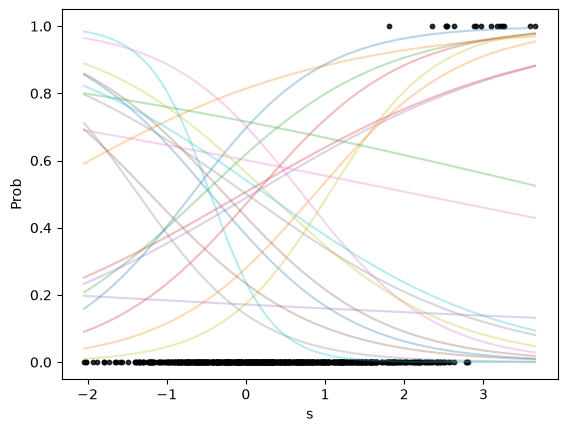

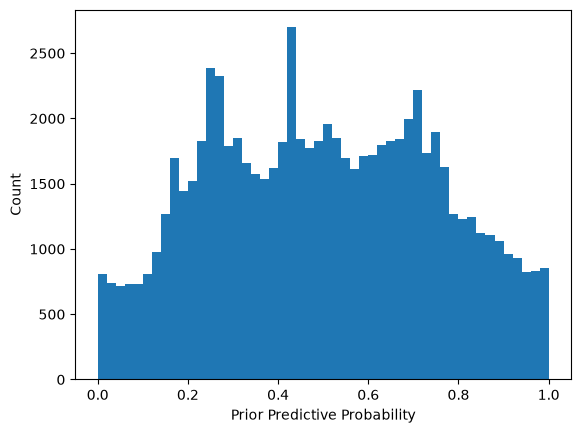

In [22]:
rng_repr_check, rng = random.split(rng, 2)
prior_prob = prior_predictive_check_glm(rng_repr_check, 'repr', glm_models, vr_data, 100, glm_priors)
plt.hist(jnp.ravel(prior_prob), bins=50)
plt.xlabel("Prior Predictive Probability")
plt.ylabel("Count")
plt.show()

In [23]:
rng_seed, rng = random.split(rng, 2)

kernel = NUTS(seed_inference_model_glm)
mcmc = MCMC(kernel, num_warmup = num_warmup, num_samples = num_samples)
mcmc.run(rng_seed, s = s_seed, y = y_seed, priors = glm_priors)
mcmc.print_summary()
seed_samples = mcmc.get_samples()


sample: 100%|██████████| 6000/6000 [00:01<00:00, 4581.88it/s, 55 steps of size 8.07e-02. acc. prob=0.94]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      1.03      0.05      1.04      0.95      1.11    634.45      1.01
     slope      2.19      0.01      2.19      2.16      2.21    635.48      1.01

Number of divergences: 0


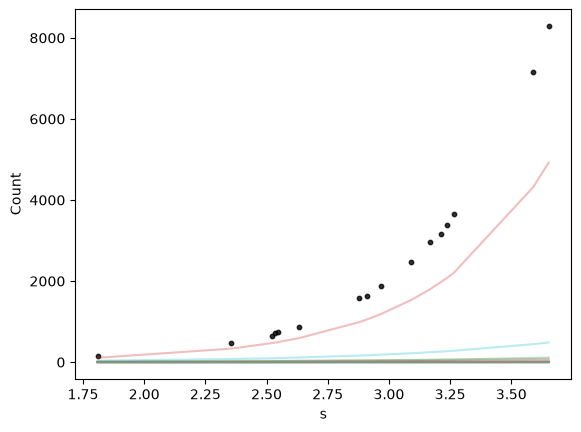

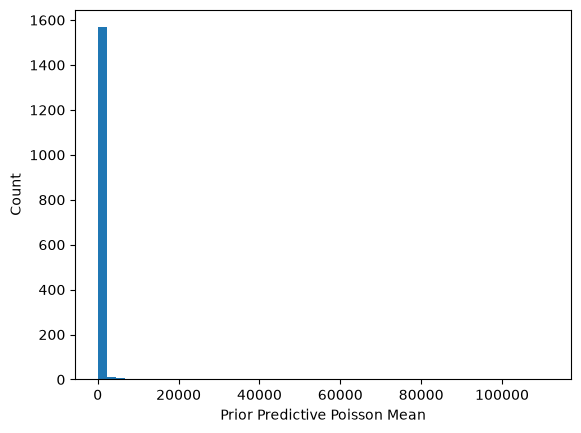

In [24]:
rng_seed_check, rng = random.split(rng, 2)
prior_mean = prior_predictive_check_glm(rng_surv_check, 'seed', glm_models, vr_data, 100, glm_priors)
plt.hist(jnp.ravel(prior_mean), bins=50)
plt.xlabel("Prior Predictive Poisson Mean")
plt.ylabel("Count")
plt.show()

In [25]:
rng_growth, rng = random.split(rng, 2)

kernel = NUTS(growth_inference_model_glm)
mcmc = MCMC(kernel, num_warmup = num_warmup, num_samples = num_samples)
mcmc.run(rng_surv, s = s_growth, y = y_growth, priors = glm_priors)
mcmc.print_summary()
growth_samples = mcmc.get_samples()


sample: 100%|██████████| 6000/6000 [00:01<00:00, 4192.60it/s, 7 steps of size 5.90e-01. acc. prob=0.92]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      1.05      0.05      1.04      0.97      1.12   2961.25      1.00
     noise      0.64      0.03      0.63      0.59      0.68   3323.94      1.00
     slope      0.54      0.04      0.54      0.48      0.61   2932.79      1.00

Number of divergences: 0


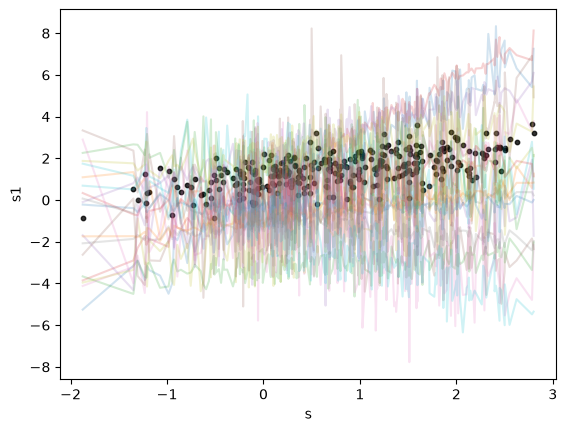

In [26]:
rng_growth_check, rng = random.split(rng, 2)
_ = prior_predictive_check_glm(rng_growth_check, 'growth', glm_models, vr_data, 100, glm_priors)


# GP Inference

In [27]:
gp_priors = {
    'surv_int': dist.Normal(0,1.0),
    'surv_var': dist.HalfNormal(1.0),
    'surv_ls': dist.HalfNormal(1.0),

    'repr_int': dist.Normal(0,1.0),
    'repr_var': dist.HalfNormal(1.0),
    'repr_ls': dist.HalfNormal(1.0),

    'seed_int': dist.Normal(0,1.0),
    'seed_var': dist.HalfNormal(1.0),
    'seed_ls': dist.HalfNormal(1.0),

    'growth_int': dist.Normal(0,1.0),
    'growth_var': dist.HalfNormal(1.0),
    'growth_ls': dist.HalfNormal(1.0),
    'growth_noise': dist.HalfNormal(1.0)
}

In [28]:
def survival_inference_model_gp(s, y , priors):
    var = numpyro.sample('var', priors['surv_var'])
    ls = numpyro.sample('ls', priors['surv_ls'])
    intercept = numpyro.sample('int', priors['surv_int'])
    z = numpyro.sample('z', dist.Normal(), sample_shape=(1,s.shape[0]))
    K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
    L_chol = jnp.linalg.cholesky(K)
    mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]) + intercept)
    p = jax.nn.sigmoid(mu)
    numpyro.sample('y_surv', dist.Bernoulli(p), obs = y)

In [29]:
def repr_inference_model_gp(s, y , priors):
    var = numpyro.sample('var', priors['repr_var'])
    ls = numpyro.sample('ls', priors['repr_ls'])
    intercept = numpyro.sample('int', priors['repr_int'])
    z = numpyro.sample('z', dist.Normal(), sample_shape=(1,s.shape[0]))
    K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
    L_chol = jnp.linalg.cholesky(K)
    mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]) + intercept)
    p = jax.nn.sigmoid(mu)
    numpyro.sample('y_repr', dist.Bernoulli(p), obs = y)

In [30]:
def seed_inference_model_gp(s, y , priors):
    var = numpyro.sample('var', priors['seed_var'])
    ls = numpyro.sample('ls', priors['seed_ls'])
    intercept = numpyro.sample('int', priors['seed_int'])
    z = numpyro.sample('z', dist.Normal(), sample_shape=(1,s.shape[0]))
    K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
    L_chol = jnp.linalg.cholesky(K)
    mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]) + intercept)
    lambda_ = jnp.exp(mu)
    numpyro.sample('y_seed', dist.Poisson(lambda_), obs = y)

In [31]:
def growth_inference_model_gp(s, y , priors):
    var = numpyro.sample('var', priors['growth_var'])
    ls = numpyro.sample('ls', priors['growth_ls'])
    intercept = numpyro.sample('int', priors['growth_int'])
    z = numpyro.sample('z', dist.Normal(), sample_shape=(1,s.shape[0]))
    noise = numpyro.sample('noise', priors['growth_noise'])
    K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
    L_chol = jnp.linalg.cholesky(K)
    mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]) + intercept)
    numpyro.sample('s1', dist.Normal(mu, noise), obs = y)

In [32]:
gp_models = {
    'surv': survival_inference_model_gp,
    'repr': repr_inference_model_gp,
    'seed': seed_inference_model_gp,
    'growth': growth_inference_model_gp
}

In [33]:
def prior_predictive_check_gp(rng, model_key, models, data, num_samples, priors):
    s = data[model_key][0]
    y = data[model_key][1]
    model = models[model_key]
    rng_mu, rng_y = random.split(rng, 2)
    if model_key == 'growth':
        prior_pred = Predictive(model, num_samples=num_samples, return_sites=['mu', 's1'],)
        prior_samples = prior_pred(rng_mu, s=s, y=None, priors=priors)
        param = prior_samples['mu']
        y_prior = prior_samples["s1"]

    else:
        prior_pred = Predictive(model, num_samples=num_samples, return_sites=['mu'],)
        prior_samples = prior_pred(rng_mu, s=s, y=None, priors=priors)
        mu_prior = prior_samples["mu"]
        if model_key == 'surv' or model_key == 'repr':
            param = jax.nn.sigmoid(mu_prior)     
        elif model_key == 'seed':
            rates = jnp.exp(mu_prior)
            poisson_draws = random.poisson(rng_y, lam=rates[:, None, :], shape=(num_samples, 3, s.shape[0]))
            param = rates

    sort_idx = jnp.argsort(s)
    s_sorted = s[sort_idx]
    y_sorted = y[sort_idx]

    if model_key == 'growth':
        for i in range(20):
            plt.plot(s_sorted, y_prior[i][sort_idx], alpha=0.2)

    elif model_key == 'seed':
        for i in range(10):
            for replicate in range(3):
                plt.scatter(s_sorted, poisson_draws[i, replicate, sort_idx],alpha=0.15, s=8)
    else:
        for i in range(20):
            plt.plot(s_sorted, param[i][sort_idx], alpha=0.3)

    plt.scatter(s_sorted, y_sorted, color="black", s=10, alpha=0.8, label="Observed data")
    plt.xlabel("s")
    if model_key == 'growth':
        plt.ylabel("s1")
    elif model_key == 'surv' or model_key == 'repr':
        plt.ylabel('Prob')
    elif model_key == 'seed':
        plt.ylabel('Count')
    plt.show()
    return param

In [34]:
rng_surv_gp, rng = random.split(rng, 2)

kernel = NUTS(survival_inference_model_gp)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_surv_gp, s=s_surv, y=y_surv, priors=gp_priors)
mcmc.print_summary()
surv_samples_gp = mcmc.get_samples() 

sample: 100%|██████████| 6000/6000 [49:17<00:00,  2.03it/s, 63 steps of size 9.88e-02. acc. prob=0.91]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -0.28      0.60     -0.29     -1.27      0.68   5784.36      1.00
        ls      1.55      0.53      1.50      0.67      2.33   3302.09      1.00
       var      1.09      0.50      1.01      0.29      1.81   6604.19      1.00
    z[0,0]     -0.66      0.63     -0.64     -1.65      0.41   5696.59      1.00
    z[0,1]     -1.43      0.54     -1.39     -2.30     -0.52   5482.32      1.00
    z[0,2]      0.37      0.72      0.32     -0.84      1.54   5950.99      1.00
    z[0,3]     -0.05      1.01     -0.07     -1.74      1.53  10371.93      1.00
    z[0,4]     -0.01      0.97      0.00     -1.57      1.61   8862.47      1.00
    z[0,5]      0.11      0.94      0.11     -1.41      1.65   9430.86      1.00
    z[0,6]      0.33      0.94      0.31     -1.25      1.85   7760.45      1.00
    z[0,7]     -0.16      0.97     -0.14     -1.78      1.42   8806.26      1.00
    z[0,8]     -0.09      0

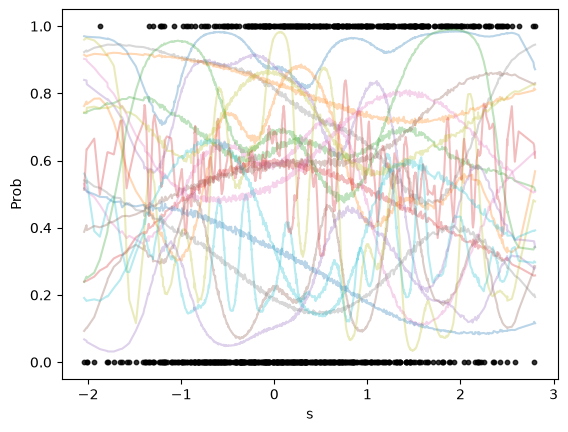

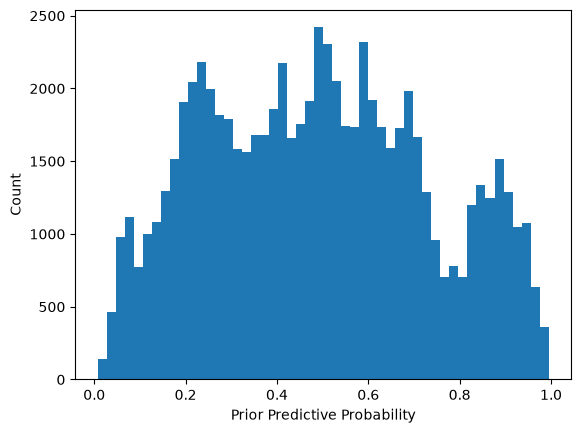

In [35]:
rng_surv_check_gp, rng = random.split(rng, 2)
prior_prob = prior_predictive_check_gp(rng_surv_check_gp, 'surv', gp_models, vr_data, 100, gp_priors)
plt.hist(jnp.ravel(prior_prob), bins=50)
plt.xlabel("Prior Predictive Probability")
plt.ylabel("Count")
plt.show()

In [36]:
rng_repr_gp, rng = random.split(rng, 2)

kernel = NUTS(repr_inference_model_gp)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_repr_gp, s=s_repr, y=y_repr, priors=gp_priors)
mcmc.print_summary()
repr_samples_gp = mcmc.get_samples() 

sample: 100%|██████████| 6000/6000 [29:00<00:00,  3.45it/s, 31 steps of size 1.14e-01. acc. prob=0.94]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int     -1.51      0.83     -1.52     -2.89     -0.17   3323.51      1.00
        ls      1.21      0.33      1.18      0.68      1.73   1066.45      1.00
       var      2.76      0.64      2.73      1.76      3.79   5477.95      1.00
    z[0,0]     -2.90      0.71     -2.88     -4.04     -1.75   2981.55      1.00
    z[0,1]     -0.26      0.85     -0.24     -1.68      1.13   2400.88      1.00
    z[0,2]     -1.23      0.84     -1.24     -2.51      0.23   3824.36      1.00
    z[0,3]     -0.07      1.00     -0.07     -1.66      1.61   8665.47      1.00
    z[0,4]      0.38      0.99      0.39     -1.43      1.85   4374.31      1.00
    z[0,5]     -0.15      0.97     -0.15     -1.72      1.46   5334.05      1.00
    z[0,6]     -0.54      1.01     -0.56     -2.22      1.08   5203.16      1.00
    z[0,7]     -0.06      1.03     -0.08     -1.68      1.67   4555.38      1.00
    z[0,8]      0.08      1

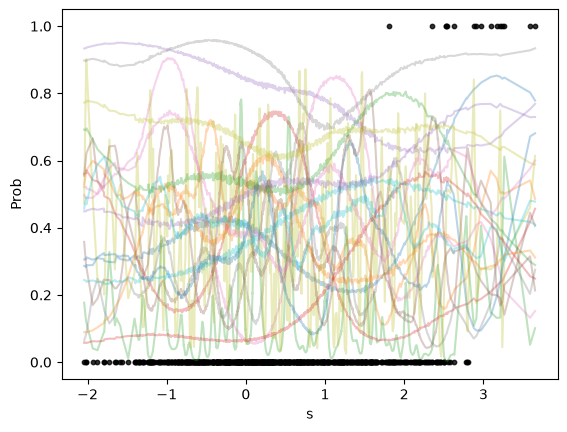

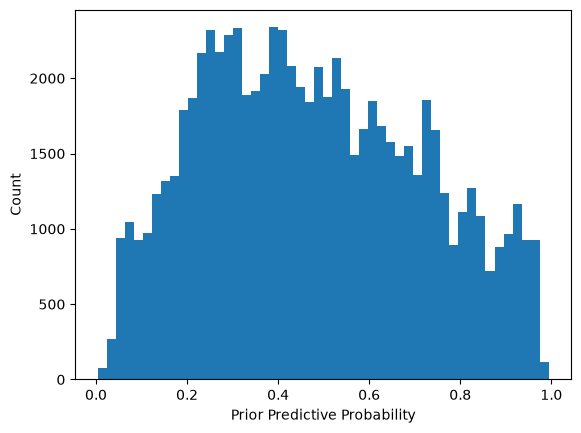

In [37]:
rng_repr_check_gp, rng = random.split(rng, 2)
prior_prob = prior_predictive_check_gp(rng_repr_check_gp, 'repr', gp_models, vr_data, 100, gp_priors)
plt.hist(jnp.ravel(prior_prob), bins=50)
plt.xlabel("Prior Predictive Probability")
plt.ylabel("Count")
plt.show()

In [38]:
rng_seed_gp, rng = random.split(rng, 2)

kernel = NUTS(seed_inference_model_gp)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_seed_gp, s=s_seed, y=y_seed, priors=gp_priors)
mcmc.print_summary()
seed_samples_gp = mcmc.get_samples() 

sample: 100%|██████████| 6000/6000 [01:36<00:00, 62.18it/s, 1023 steps of size 3.66e-03. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      2.62      0.90      2.63      1.17      4.12   2214.89      1.00
        ls      1.67      0.46      1.62      0.96      2.40   1043.49      1.00
       var      2.97      0.63      2.92      1.94      3.99   3959.36      1.00
    z[0,0]      2.27      0.48      2.28      1.49      3.05   2278.88      1.00
    z[0,1]     -1.95      0.58     -1.89     -2.88     -1.04   1176.48      1.00
    z[0,2]      2.36      0.58      2.34      1.35      3.25   2751.25      1.00
    z[0,3]     -0.35      0.81     -0.34     -1.70      0.95   4480.34      1.00
    z[0,4]      0.02      0.77      0.03     -1.21      1.30   4572.76      1.00
    z[0,5]     -0.30      0.73     -0.30     -1.55      0.86   4912.32      1.00
    z[0,6]      0.49      0.87      0.49     -0.95      1.90   5305.07      1.00
    z[0,7]      1.41      0.65      1.41      0.37      2.46   3811.14      1.00
    z[0,8]      1.47      0

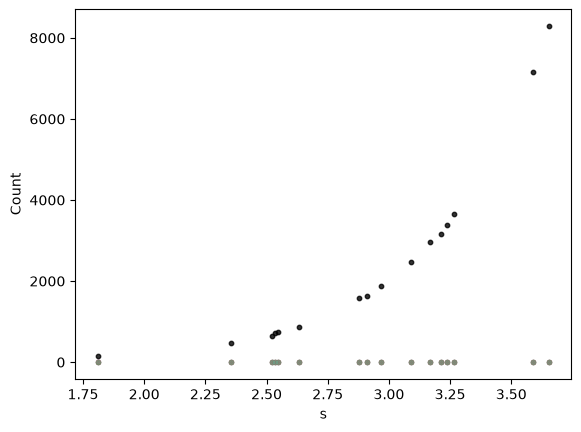

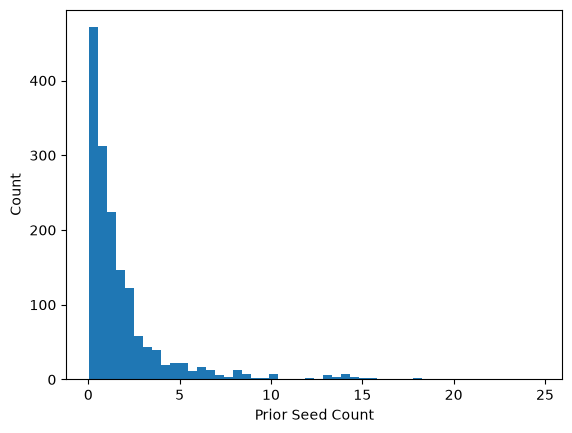

In [39]:
rng_seed_check_gp, rng = random.split(rng, 2)
prior_count = prior_predictive_check_gp(rng_seed_check_gp, 'seed', gp_models, vr_data, 100, gp_priors)
plt.hist(jnp.ravel(prior_count), bins=50)
plt.xlabel("Prior Seed Count")
plt.ylabel("Count")
plt.show()

In [40]:
rng_growth_gp, rng = random.split(rng, 2)

kernel = NUTS(growth_inference_model_gp)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_seed_gp, s=s_growth, y=y_growth, priors=gp_priors)
mcmc.print_summary()
growth_samples_gp = mcmc.get_samples() 

sample: 100%|██████████| 6000/6000 [13:59<00:00,  7.15it/s, 127 steps of size 4.69e-02. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       int      0.92      0.62      0.94     -0.07      1.97   5640.58      1.00
        ls      1.84      0.55      1.78      0.98      2.70   2846.71      1.00
     noise      0.64      0.03      0.64      0.59      0.68  10525.01      1.00
       var      1.15      0.55      1.06      0.27      1.93   6331.32      1.00
    z[0,0]      0.14      0.60      0.15     -0.83      1.17   6076.37      1.00
    z[0,1]     -0.98      0.48     -0.93     -1.75     -0.24   4711.12      1.00
    z[0,2]     -0.61      0.76     -0.60     -1.87      0.62   6339.52      1.00
    z[0,3]      0.19      0.85      0.19     -1.21      1.56   9302.80      1.00
    z[0,4]      0.33      0.92      0.35     -1.18      1.85   9162.05      1.00
    z[0,5]     -0.04      1.02     -0.05     -1.67      1.71  11025.10      1.00
    z[0,6]      0.42      0.89      0.41     -1.02      1.89   9372.31      1.00
    z[0,7]      0.17      1

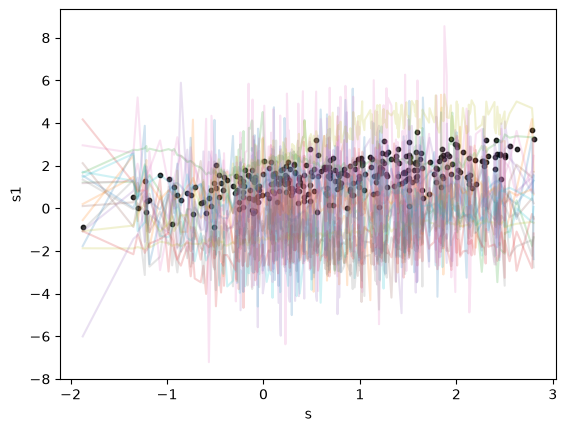

In [41]:
rng_growth_check_gp, rng = random.split(rng, 2)
_ = prior_predictive_check_gp(rng_growth_check_gp, 'growth', gp_models, vr_data, 100, gp_priors)

In [42]:
# Recruitment Probability
n_recruits = int(((df["age"] == 0) & df["z"].notna()).sum())
total_seeds = int(np.nansum(df["Seeds"]))

if total_seeds == 0:
    raise ValueError("Recruitment probability cannot be estimated because total seed production is zero.")

if n_recruits > total_seeds:
    raise ValueError("The number of recruits cannot exceed the number of seeds.")

p_recruit_est = n_recruits / total_seeds

print("New recruits:", n_recruits)
print("Total seeds:", total_seeds)
print("Recruitment probability:", p_recruit_est)

New recruits: 522
Total seeds: 39746
Recruitment probability: 0.013133397071403412


In [43]:
# Recruit Density
from scipy import stats

recruit_sizes = df.loc[(df["age"] == 0) & df["z"].notna(), "z"].to_numpy()
recruit_mean_est, recruit_sd_est = stats.norm.fit(recruit_sizes)

print("Recruitment mean:", recruit_mean_est)
print("Recruitment SD:", recruit_sd_est)

Recruitment mean: -0.03499747386292291
Recruitment SD: 0.7452146106964116


In [44]:
glm_post_samples = {
    'surv': surv_samples,
    'repr': repr_samples,
    'seed': seed_samples,
    'growth': growth_samples,
    'recr': {
        'prob': p_recruit_est,
        'mean': recruit_mean_est,
        'sd': recruit_sd_est
    }
}

gp_post_samples = {
    'surv': surv_samples_gp,
    'repr': repr_samples_gp,
    'seed': seed_samples_gp,
    'growth': growth_samples_gp,
    'recr': {
        'prob': p_recruit_est,
        'mean': recruit_mean_est,
        'sd': recruit_sd_est
    }
}

In [45]:
glm_samples_flatten = {
    f"{group}_{name}": np.asarray(jax.device_get(value))
    for group, group_samples in glm_post_samples.items()
    for name, value in group_samples.items()
}

In [46]:
np.savez_compressed(
    'gpdf_glm_samples.npz',
    **glm_samples_flatten
    )


In [47]:
gp_samples_flatten = {
    f"{group}_{name}": np.asarray(jax.device_get(value))
    for group, group_samples in gp_post_samples.items()
    for name, value in group_samples.items()
}

In [48]:
np.savez_compressed(
    'gpdf_gp_samples.npz',
    **gp_samples_flatten
    )